# plotting FAC monthly for Emily (PSU)

In [2]:
# import dependencies

import xarray as xr

In [3]:
filepath = "/home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process/FDM_FirnAir_FGRN055_1939-2023_monthly_detrended.nc"
ds = xr.open_dataset(filepath)
ds

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 1012, rlat: 566, rlon: 438)
Coordinates:
  * time          (time) datetime64[ns] 8kB 1939-09-15 1939-10-15 ... 2023-12-15
  * rlat          (rlat) float32 2kB -14.4 -14.35 -14.3 ... 13.75 13.8 13.85
  * rlon          (rlon) float32 2kB -10.05 -10.0 -9.95 -9.9 ... 11.7 11.75 11.8
    lat           (rlat, rlon) float32 992kB ...
    lon           (rlat, rlon) float32 992kB ...
Data variables:
    FirnAir       (time, rlat, rlon) float32 1GB ...
    y_FDM         (rlat) int32 2kB ...
    x_FDM         (rlon) int32 2kB ...
    rotated_pole  int32 4B ...
    crs           int32 4B ...
    x             (rlat, rlon) float32 992kB ...
    y             (rlat, rlon) float32 992kB ...
Attributes:
    title:             IMAU-FDM gridded output: Firn air content
    source:            IMAU-FDM version 1.2+
    domain:            FGRN055
    institution:       IMAU, Utrecht University
    history:           Created on 2026-03-24T09:28:04.360123
    time_aggregation:  monthly
    Conventions:       CF-1.8

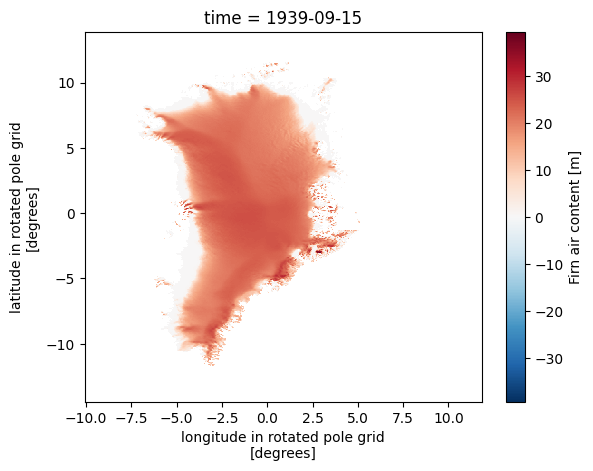

In [13]:
ds.FirnAir.isel(time=0).plot()

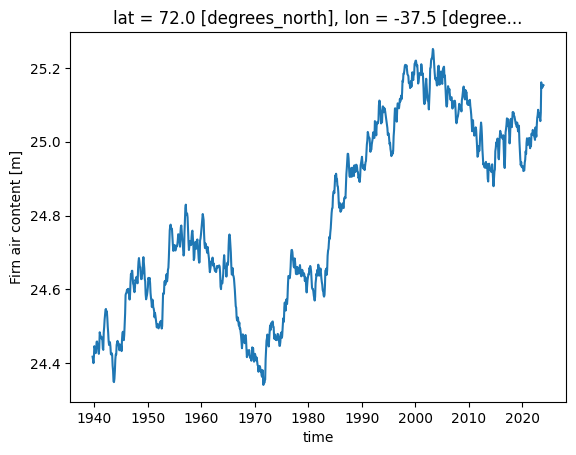

In [14]:
ds.FirnAir.sel(rlat=0,rlon=0).plot()

# Trying to figure out what's going on with the CRS in the FAC files

In [2]:
path_to_file = "/home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process/FDM_FirnAir_FGRN055_1939-2023_10day_detrended.nc"
ds = xr.load_dataset(path_to_file)

path_racmo = "/home/nld4814/scratch/FGRN055_era055/input/averages/evap_FGRN055_era055-1939_1940-1970_ave.nc"
ds_racmo = xr.load_dataset(path_racmo)


In [5]:
ds = ds.rename({"rlat":"rlat_FDM", "rlon":"rlon_FDM"})

In [6]:
ds = ds.assign_coords(rlat=ds_racmo["rlat"],
                 rlon=ds_racmo["rlon"])

In [8]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:   (time: 3081, rlat_FDM: 566, rlon_FDM: 438, rlat: 566, rlon: 438)
Coordinates:
  * time      (time) float64 25kB 1.94e+03 1.94e+03 ... 2.024e+03 2.024e+03
  * rlat_FDM  (rlat_FDM) float32 2kB 0.0 1.0 2.0 3.0 ... 562.0 563.0 564.0 565.0
  * rlon_FDM  (rlon_FDM) float32 2kB 0.0 1.0 2.0 3.0 ... 434.0 435.0 436.0 437.0
  * rlat      (rlat) float64 5kB -14.4 -14.35 -14.3 -14.25 ... 13.75 13.8 13.85
  * rlon      (rlon) float64 4kB -10.05 -10.0 -9.95 -9.9 ... 11.7 11.75 11.8
    lat       (rlat_FDM, rlon_FDM) float32 992kB 56.12 56.13 ... 77.97 77.92
    lon       (rlat_FDM, rlon_FDM) float32 992kB -55.15 -55.07 ... 34.02 34.11
Data variables:
    FirnAir   (time, rlat_FDM, rlon_FDM) float32 3GB nan nan nan ... nan nan nan
    crs       int32 4B -2147483647
    x         (rlat_FDM, rlon_FDM) float32 992kB -6.656e+05 ... 1.289e+06
    y         (rlat_FDM, rlon_FDM) float32 992kB -3.718e+06 ... -2.482e+05
Attributes:
    title:             IMAU-FDM gridded output: Firn air content
    source:            IMAU-FDM version 1.2+
    domain:            FGRN055
    institution:       IMAU, Utrecht University
    time_aggregation:  10day
    Conventions:       CF-1.8
    history:           Created on 2026-01-28T16:30:25.362179\n2026-03-02T09:2...

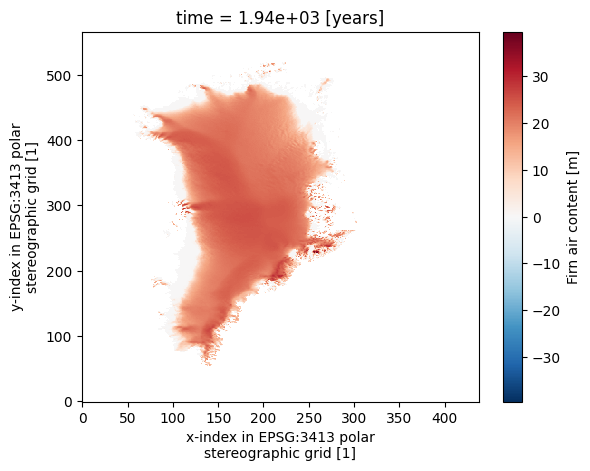

In [7]:
ds.FirnAir.isel(time=0).plot()

In [9]:
ds["rotated_pole"] = ds_racmo["rotated_pole"]

In [ ]:
ds = ds.drop_vars("crs")
ds = ds.drop_vars("x")

TypeError: Dataset.drop_vars() got an unexpected keyword argument 'inplace'

In [5]:
ds['FirnAir'].rio.write_crs('EPSG:3413').rio.reproject('EPSG:3413').rio.to_raster('output.tif')

: 

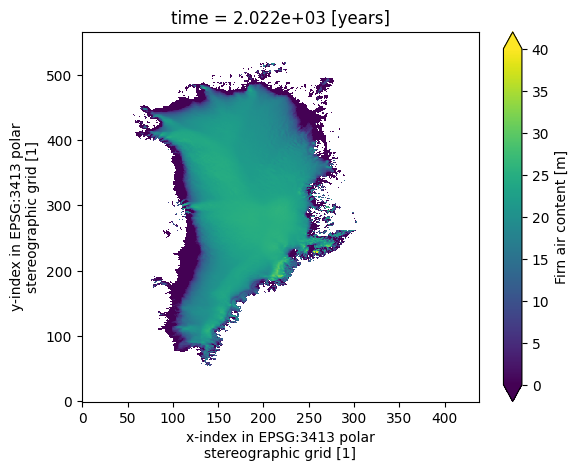

In [10]:
ds.FirnAir.isel(time=3000).plot(vmin=0,vmax=40)

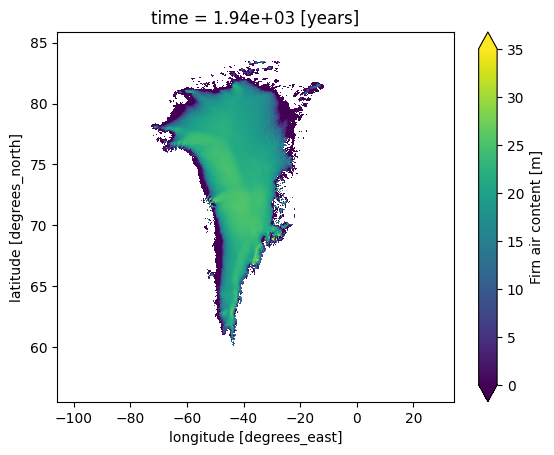

In [13]:
ds.FirnAir.isel(time=0).plot(x="lon",y="lat",vmin=0,vmax=35)

In [ ]:
ds = xr.open_dataset('file.nc').rio.set_spatial_dims('rlon', 'rlat')
ds['variable'].rio.write_crs('EPSG:3413').rio.reproject('EPSG:3413').rio.to_raster('output.tif’)

In [5]:
# import racmo data

path_racmo = "/home/nld4814/scratch/FGRN055_era055/input/averages/evap_FGRN055_era055-1939_1940-1970_ave.nc"
ds_racmo = xr.load_dataset(path_racmo)

In [7]:
ds_racmo.rotated_pole

<xarray.DataArray 'rotated_pole' ()> Size: 4B
array(9.96921e+36, dtype=float32)
Attributes:
    grid_mapping_name:          rotated_latitude_longitude
    grid_north_pole_latitude:   18.0
    grid_north_pole_longitude:  142.5
    proj4_params:               -m 57.295779506 +proj=ob_tran +o_proj=latlon ...
    proj_parameters:            -m 57.295779506 +proj=ob_tran +o_proj=latlon ...
    projection_name:            rotated_latitude_longitude
    long_name:                  projection details
    EPSG_code:

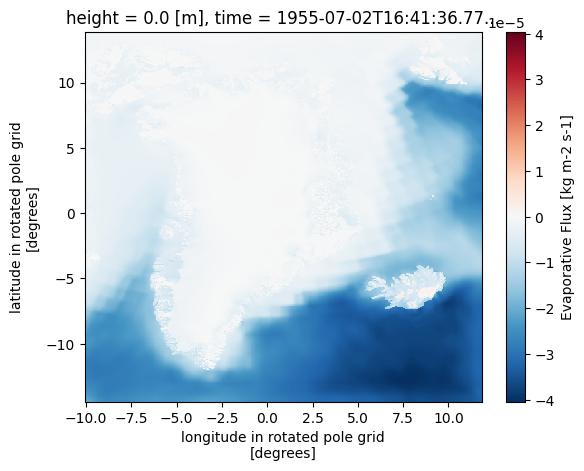

In [9]:
ds_racmo.evap.plot()

In [3]:
ds_test = xr.load_dataset("/home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process/_test_z830_updated.nc")

In [4]:
ds_test

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 1026, rlat: 566, rlon: 438)
Coordinates:
  * time          (time) float64 8kB 1.94e+03 1.94e+03 ... 2.024e+03 2.024e+03
  * rlat          (rlat) float32 2kB -14.4 -14.35 -14.3 ... 13.75 13.8 13.85
  * rlon          (rlon) float32 2kB -10.05 -10.0 -9.95 -9.9 ... 11.7 11.75 11.8
    lat           (rlat, rlon) float32 992kB 56.12 56.13 56.15 ... 77.97 77.92
    lon           (rlat, rlon) float32 992kB -55.15 -55.07 ... 34.02 34.11
Data variables:
    z830          (time, rlat, rlon) float32 1GB nan nan nan nan ... nan nan nan
    rotated_pole  int32 4B 0
    y_FDM         (rlat) int32 2kB 0 1 2 3 4 5 6 ... 559 560 561 562 563 564 565
    x_FDM         (rlon) int32 2kB 0 1 2 3 4 5 6 ... 431 432 433 434 435 436 437
Attributes:
    title:        IMAU-FDM gridded output: z830
    source:       IMAU-FDM version 1.2+
    domain:       FGRN055
    institution:  IMAU, Utrecht University
    Conventions:  CF-1.8
    history:      Created on 2026-02-03T16:19:30.576450\n2026-03-02T09:23:28....

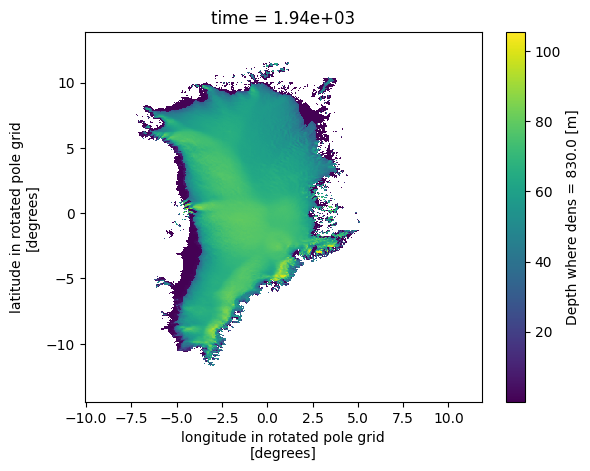

In [5]:
ds_test.z830.isel(time=0).plot()

In [6]:
ds = xr.load_dataset("/home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process/FDM_FirnAir_FGRN055_1939-2023_10day_detrended.nc")

In [ ]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:       (time: 3081, rlat: 566, rlon: 438)
Coordinates:
  * time          (time) float64 25kB 1.94e+03 1.94e+03 ... 2.024e+03 2.024e+03
  * rlat          (rlat) float32 2kB -14.4 -14.35 -14.3 ... 13.75 13.8 13.85
  * rlon          (rlon) float32 2kB -10.05 -10.0 -9.95 -9.9 ... 11.7 11.75 11.8
    lat           (rlat, rlon) float32 992kB 56.12 56.13 56.15 ... 77.97 77.92
    lon           (rlat, rlon) float32 992kB -55.15 -55.07 ... 34.02 34.11
Data variables:
    FirnAir       (time, rlat, rlon) float32 3GB nan nan nan nan ... nan nan nan
    rotated_pole  int32 4B 0
    y_FDM         (rlat) int32 2kB 0 1 2 3 4 5 6 ... 559 560 561 562 563 564 565
    x_FDM         (rlon) int32 2kB 0 1 2 3 4 5 6 ... 431 432 433 434 435 436 437
Attributes:
    title:             IMAU-FDM gridded output: Firn air content
    source:            IMAU-FDM version 1.2+
    domain:            FGRN055
    institution:       IMAU, Utrecht University
    time_aggregation:  10day
    Conventions:       CF-1.8
    history:           Created on 2026-01-28T16:30:25.362179\n2026-03-02T09:2...

: 